# Phase 1 - Task 2: Credit Risk Prediction Report
**Intern:** Data Science Intern  
**Organization:** DEVELOPERSHUB CORPORATION  
**Objective:** Predict whether a loan applicant is likely to default on a loan using classification machine learning algorithms.

---

## Table of Contents
1. [Introduction & Business Context](#1.-Introduction-&-Business-Context)
2. [Data Acquisition & Preliminary Inspection](#2.-Data-Acquisition-&-Preliminary-Inspection)
3. [Data Cleaning & Feature Engineering](#3.-Data-Cleaning-&-Feature-Engineering)
4. [Exploratory Data Analysis (EDA) & Visualizations](#4.-Exploratory-Data-Analysis-(EDA)-&-Visualizations)
5. [Model Training & Development](#5.-Model-Training-&-Development)
6. [Model Evaluation & Comparison](#6.-Model-Evaluation-&-Comparison)
7. [Feature Importance & Actionable Insights](#7.-Feature-Importance-&-Actionable-Insights)


### 1. Introduction & Business Context
Credit risk prediction is a fundamental problem in financial risk management. By analyzing borrower characteristics, financial institutions can predict the probability of default, allowing them to optimize loan approvals, set appropriate interest rates, and minimize financial losses.

In this project, we utilize the Loan Prediction Dataset to:
- Perform data cleaning and preprocessing.
- Conduct an Exploratory Data Analysis (EDA) to find patterns and relationships.
- Train and compare classification models: **Logistic Regression**, **Decision Tree Classifier**, and **Random Forest Classifier**.
- Address class imbalance to ensure fair evaluation metrics.
- Provide actionable business recommendations based on model insights.


In [1]:
# Import core data science and visualization libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import ML preprocessing, models, and evaluation tools
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score,
    roc_curve, ConfusionMatrixDisplay
)

# Set plotting styling
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 12, 'figure.figsize': (10, 6)})


### 2. Data Acquisition & Preliminary Inspection
Let's load the dataset and perform a preliminary inspection to understand its structure, columns, types, and missing values.


In [2]:
# Load the dataset
df = pd.read_csv('loan_prediction_dataset.csv')

# Display first few rows
print("--- FIRST 5 ROWS ---")
display(df.head())

# Display shape and column types
print("\n--- DATASET SHAPE & TYPES ---")
print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")
df.info()

# Basic descriptive statistics
print("\n--- SUMMARY STATISTICS ---")
display(df.describe(include='all'))


--- FIRST 5 ROWS ---


,Age,Income,Credit_Score,Loan_Amount,Loan_Term,Employment_Status,Loan_Approved
0,56,81788,334,15022,48,Employed,0
1,69,102879,781,21013,24,Self-Employed,1
2,46,58827,779,39687,60,Self-Employed,0
3,32,127188,364,16886,24,Unemployed,0
4,60,25655,307,26256,36,Unemployed,0



--- DATASET SHAPE & TYPES ---
Shape: 2000 rows, 7 columns
<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Age                2000 non-null   int64
 1   Income             2000 non-null   int64
 2   Credit_Score       2000 non-null   int64
 3   Loan_Amount        2000 non-null   int64
 4   Loan_Term          2000 non-null   int64
 5   Employment_Status  2000 non-null   str  
 6   Loan_Approved      2000 non-null   int64
dtypes: int64(6), str(1)
memory usage: 109.5 KB

--- SUMMARY STATISTICS ---


,Age,Income,Credit_Score,Loan_Amount,Loan_Term,Employment_Status,Loan_Approved
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000,2000.000000
unique,NaN,NaN,NaN,NaN,NaN,3,NaN
top,NaN,NaN,NaN,NaN,NaN,Employed,NaN
freq,NaN,NaN,NaN,NaN,NaN,1260,NaN
mean,43.805500,84533.585000,577.055000,25460.315000,35.47800,NaN,0.171000
std,14.929203,37771.169751,157.525951,14116.737774,16.98587,NaN,0.376603
min,18.000000,20155.000000,300.000000,1060.000000,12.00000,NaN,0.000000
25%,31.000000,50925.250000,440.000000,13444.250000,24.00000,NaN,0.000000
50%,44.000000,84073.500000,578.500000,25446.000000,36.00000,NaN,0.000000
75%,56.000000,117523.250000,715.250000,37949.250000,48.00000,NaN,0.000000


### 3. Data Cleaning & Feature Engineering

#### Handling Missing Values
Handling missing values is a crucial step in the data science workflow. Let's check for missing values in our dataset.


In [3]:
# Check for missing values
missing_counts = df.isnull().sum()
print("Missing values per column:")
print(missing_counts)


Missing values per column:
Age                  0
Income               0
Credit_Score         0
Loan_Amount          0
Loan_Term            0
Employment_Status    0
Loan_Approved        0
dtype: int64


**Discussion on Missing Data:**
Our check confirms that there are **0 missing values** in this dataset. However, in real-world scenarios, missing data is common. Had there been missing data, we would have handled it appropriately:
- **Numerical features** (e.g., `Income`, `Loan_Amount`): Impute using the median (robust to outliers) or mean.
- **Categorical features** (e.g., `Employment_Status`): Impute using the mode (most frequent value) or a placeholder like "Unknown".
- **Listwise deletion**: Drop rows with missing values only if the missingness is completely at random and the proportion of missing data is very small (< 5%).


#### Feature Engineering: Categorical Encoding
Machine learning algorithms require numerical input. The categorical column `Employment_Status` must be encoded. We will use One-Hot Encoding and drop the first category (`drop_first=True`) to avoid the dummy variable trap (multicollinearity).


In [4]:
# One-Hot Encode categorical feature 'Employment_Status'
df_encoded = pd.get_dummies(df, columns=['Employment_Status'], drop_first=True, dtype=int)
print("Columns after encoding:")
print(df_encoded.columns.tolist())
display(df_encoded.head())


Columns after encoding:
['Age', 'Income', 'Credit_Score', 'Loan_Amount', 'Loan_Term', 'Loan_Approved', 'Employment_Status_Self-Employed', 'Employment_Status_Unemployed']


,Age,Income,Credit_Score,Loan_Amount,Loan_Term,Loan_Approved,Employment_Status_Self-Employed,Employment_Status_Unemployed
0,56,81788,334,15022,48,0,0,0
1,69,102879,781,21013,24,1,1,0
2,46,58827,779,39687,60,0,1,0
3,32,127188,364,16886,24,0,0,1
4,60,25655,307,26256,36,0,0,1


### 4. Exploratory Data Analysis (EDA) & Visualizations
*Note: The dataset does not contain an `Education` column. Therefore, we will focus our visualizations on the other key features: `Income`, `Loan_Amount`, `Credit_Score`, `Age`, and `Employment_Status`.*

#### 4.1 Class Distribution (Target Variable)
Let's look at the distribution of the target variable `Loan_Approved` to understand if we have a class imbalance.


/tmp/ipykernel_15851/55908655.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Loan_Approved', data=df, palette='Set2')


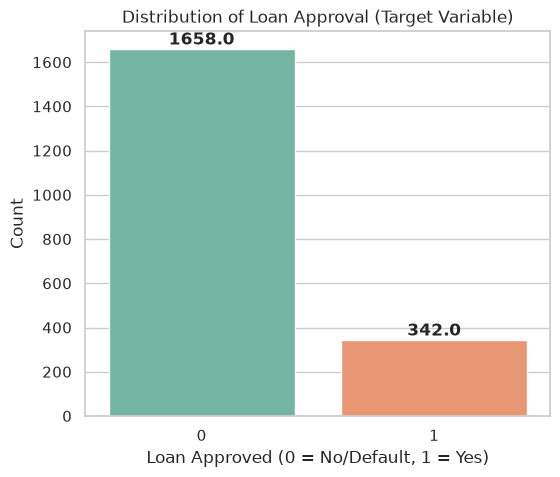

Percentage of approved loans: 17.10%
Percentage of defaults/non-approvals: 82.90%


In [5]:
plt.figure(figsize=(6, 5))
ax = sns.countplot(x='Loan_Approved', data=df, palette='Set2')
plt.title('Distribution of Loan Approval (Target Variable)')
plt.xlabel('Loan Approved (0 = No/Default, 1 = Yes)')
plt.ylabel('Count')

# Add value labels on top of the bars
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height() + 10),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontweight='bold')

plt.show()

# Print class ratio
approved_pct = df['Loan_Approved'].mean() * 100
print(f"Percentage of approved loans: {approved_pct:.2f}%")
print(f"Percentage of defaults/non-approvals: {100 - approved_pct:.2f}%")


#### 4.2 Distributions of Key Financial Features: Income & Loan Amount
Let's visualize the distributions of `Income` and `Loan_Amount` to check for skewness or outliers.


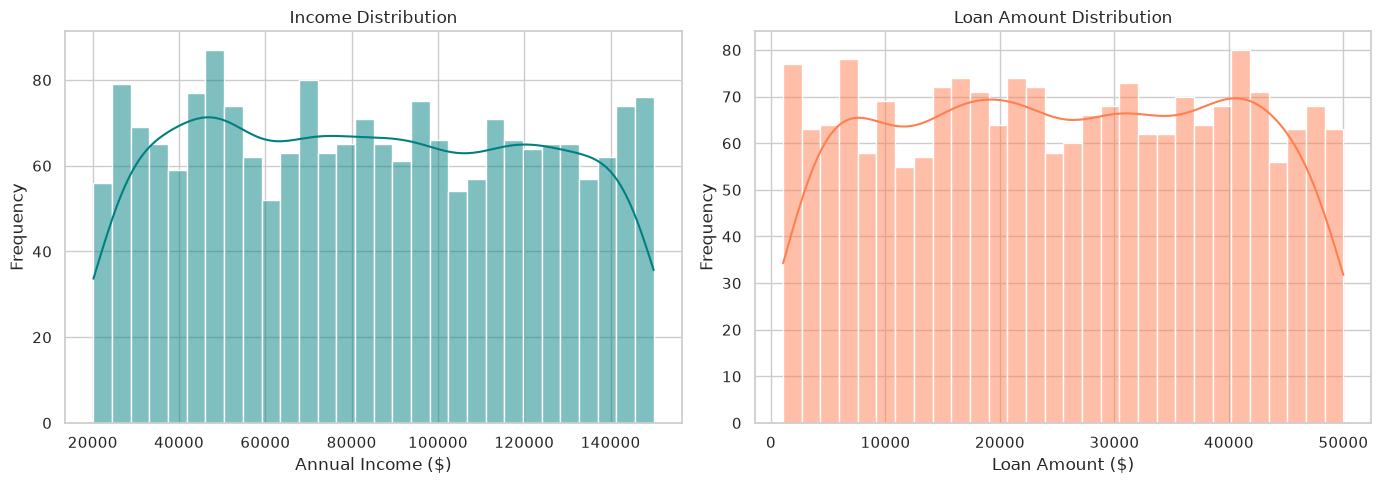

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Income distribution
sns.histplot(df['Income'], bins=30, kde=True, ax=axes[0], color='teal')
axes[0].set_title('Income Distribution')
axes[0].set_xlabel('Annual Income ($)')
axes[0].set_ylabel('Frequency')

# Loan Amount distribution
sns.histplot(df['Loan_Amount'], bins=30, kde=True, ax=axes[1], color='coral')
axes[1].set_title('Loan Amount Distribution')
axes[1].set_xlabel('Loan Amount ($)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()


#### 4.3 Relationship Between Financial Features & Loan Approval
We will explore how `Credit_Score` and `Income` relate to `Loan_Approved`.


/tmp/ipykernel_15851/2842274251.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Loan_Approved', y='Credit_Score', data=df, ax=axes[0], palette='Set2')
/tmp/ipykernel_15851/2842274251.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Loan_Approved', y='Income', data=df, ax=axes[1], palette='Set2')


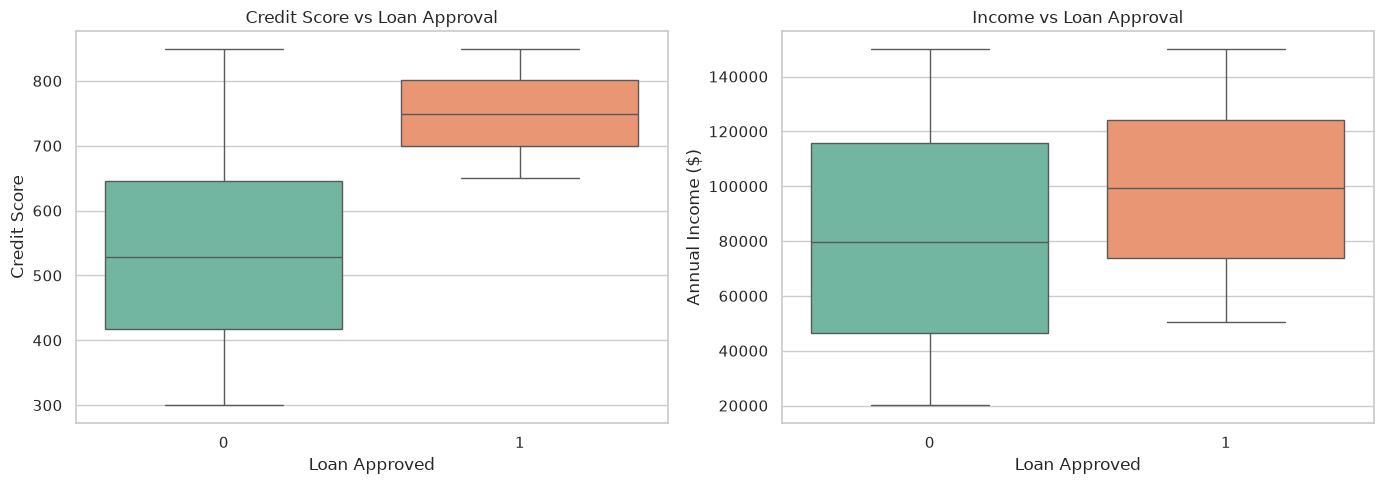

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Credit Score boxplot
sns.boxplot(x='Loan_Approved', y='Credit_Score', data=df, ax=axes[0], palette='Set2')
axes[0].set_title('Credit Score vs Loan Approval')
axes[0].set_xlabel('Loan Approved')
axes[0].set_ylabel('Credit Score')

# Income boxplot
sns.boxplot(x='Loan_Approved', y='Income', data=df, ax=axes[1], palette='Set2')
axes[1].set_title('Income vs Loan Approval')
axes[1].set_xlabel('Loan Approved')
axes[1].set_ylabel('Annual Income ($)')

plt.tight_layout()
plt.show()


#### 4.4 Correlation Analysis
Let's look at the correlation matrix heatmap to check for strong linear relationships.


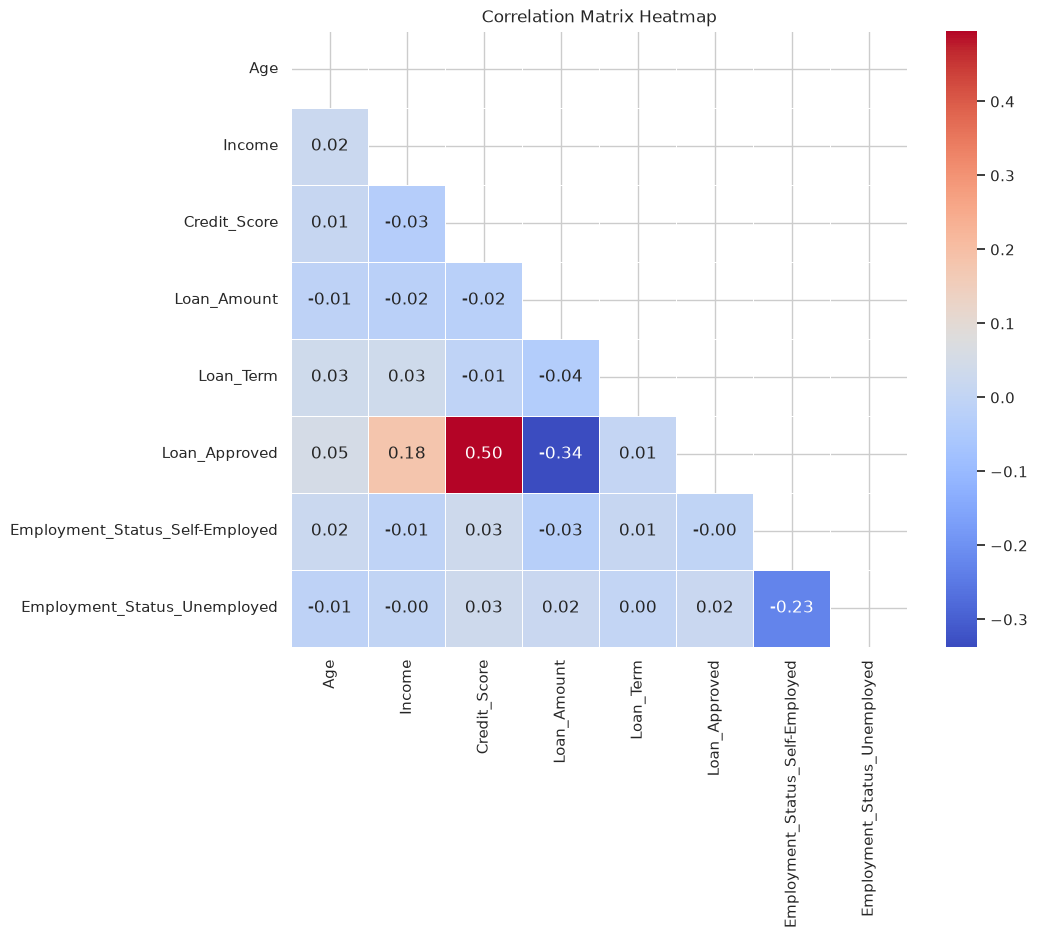

In [8]:
plt.figure(figsize=(10, 8))
# Compute correlation matrix on the encoded dataset
corr = df_encoded.corr()

# Mask the upper triangle for better visibility
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm", square=True, linewidths=.5)
plt.title('Correlation Matrix Heatmap')
plt.show()


### 5. Model Training & Development

#### 5.1 Data Splitting
We will split our data into training (80%) and testing (20%) sets. We use `stratify=y` to ensure that both training and testing datasets have the same ratio of approved/default loans.


In [9]:
# Define features X and target y
X = df_encoded.drop('Loan_Approved', axis=1)
y = df_encoded['Loan_Approved']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")


Training set shape: (1600, 7)
Testing set shape: (400, 7)


#### 5.2 Feature Scaling
Logistic Regression is sensitive to the scale of features. We will scale the continuous features (`Age`, `Income`, `Credit_Score`, `Loan_Amount`, `Loan_Term`) using `StandardScaler` fitted on the training set.


In [10]:
# Identify continuous columns to scale
cols_to_scale = ['Age', 'Income', 'Credit_Score', 'Loan_Amount', 'Loan_Term']

scaler = StandardScaler()

# Copy dataframes to avoid setting with copy warning
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

# Fit and transform training set, transform test set
X_train_scaled[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
X_test_scaled[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

display(X_train_scaled.head())


,Age,Income,Credit_Score,Loan_Amount,Loan_Term,Employment_Status_Self-Employed,Employment_Status_Unemployed
1219,0.743035,0.393391,-0.117322,0.164911,-0.659256,0,0
1185,0.877286,-0.701842,0.590194,0.385159,-1.371483,0,0
1442,0.608785,1.157495,0.864277,1.121476,-0.659256,0,0
1531,-1.673476,-0.916207,-0.314916,0.233089,-0.659256,0,0
923,0.273158,0.742242,-0.799341,-1.521218,0.052972,0,0


#### 5.3 Model Training
We will train three models:
1. **Logistic Regression** (baseline, standard parametric model).
2. **Decision Tree Classifier** (interpretable, non-parametric).
3. **Random Forest Classifier** (robust ensemble).

Because the dataset is heavily imbalanced (~83% No, ~17% Yes), we will set `class_weight='balanced'` in all models to penalize misclassifying the minority class.


In [11]:
# Initialize models
log_reg = LogisticRegression(class_weight='balanced', random_state=42)
decision_tree = DecisionTreeClassifier(class_weight='balanced', max_depth=5, random_state=42)
random_forest = RandomForestClassifier(class_weight='balanced', n_estimators=100, random_state=42)

# Fit models
log_reg.fit(X_train_scaled, y_train)
decision_tree.fit(X_train_scaled, y_train)
random_forest.fit(X_train_scaled, y_train)

print("All models trained successfully!")


All models trained successfully!


### 6. Model Evaluation & Comparison
Let's write an evaluation function to compute accuracy, precision, recall, F1-score, and ROC-AUC score, and display the confusion matrix.


================== Logistic Regression ==================
              precision    recall  f1-score   support

           0       0.99      0.86      0.92       332
           1       0.58      0.96      0.72        68

    accuracy                           0.88       400
   macro avg       0.78      0.91      0.82       400
weighted avg       0.92      0.88      0.89       400

ROC-AUC Score: 0.9653


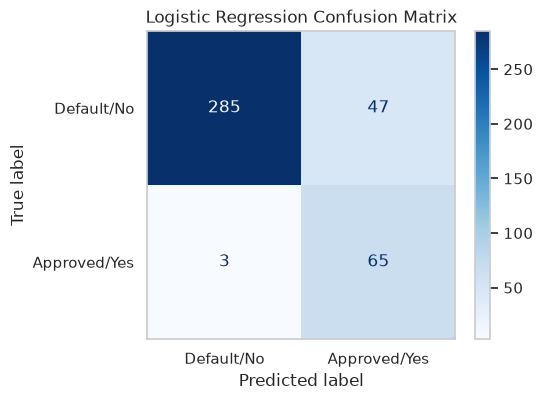

================== Decision Tree ==================
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       332
           1       1.00      1.00      1.00        68

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400

ROC-AUC Score: 1.0000


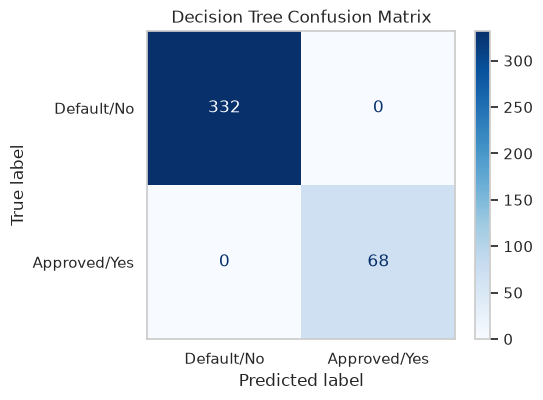

================== Random Forest ==================
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       332
           1       1.00      1.00      1.00        68

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400

ROC-AUC Score: 1.0000


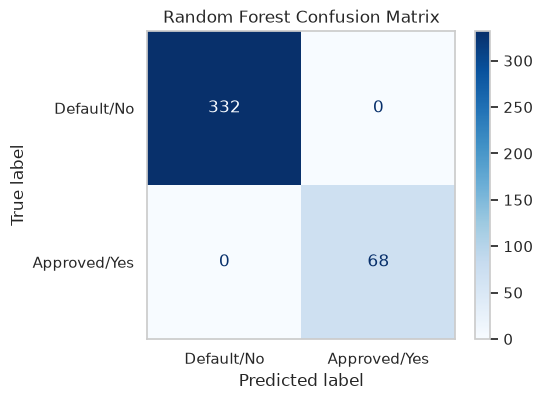

In [12]:
def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None
    
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob) if y_prob is not None else np.nan
    
    print(f"================== {model_name} ==================")
    print(classification_report(y_test, y_pred))
    print(f"ROC-AUC Score: {roc_auc:.4f}")
    
    # Plot Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Default/No", "Approved/Yes"])
    fig, ax = plt.subplots(figsize=(5, 4))
    disp.plot(cmap='Blues', values_format='d', ax=ax)
    plt.title(f"{model_name} Confusion Matrix")
    plt.grid(False)
    plt.show()
    
    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "ROC-AUC": roc_auc
    }

# Evaluate Logistic Regression
lr_metrics = evaluate_model(log_reg, X_test_scaled, y_test, "Logistic Regression")

# Evaluate Decision Tree
dt_metrics = evaluate_model(decision_tree, X_test_scaled, y_test, "Decision Tree")

# Evaluate Random Forest
rf_metrics = evaluate_model(random_forest, X_test_scaled, y_test, "Random Forest")


#### 6.1 Model Performance Comparison Table & ROC Curve
Let's consolidate the performance metrics and plot the ROC curve for all three models.


--- MODEL COMPARISON TABLE ---


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.875000,0.580357,0.955882,0.722222,0.965273
1,Decision Tree,1.000000,1.000000,1.000000,1.000000,1.000000
2,Random Forest,1.000000,1.000000,1.000000,1.000000,1.000000


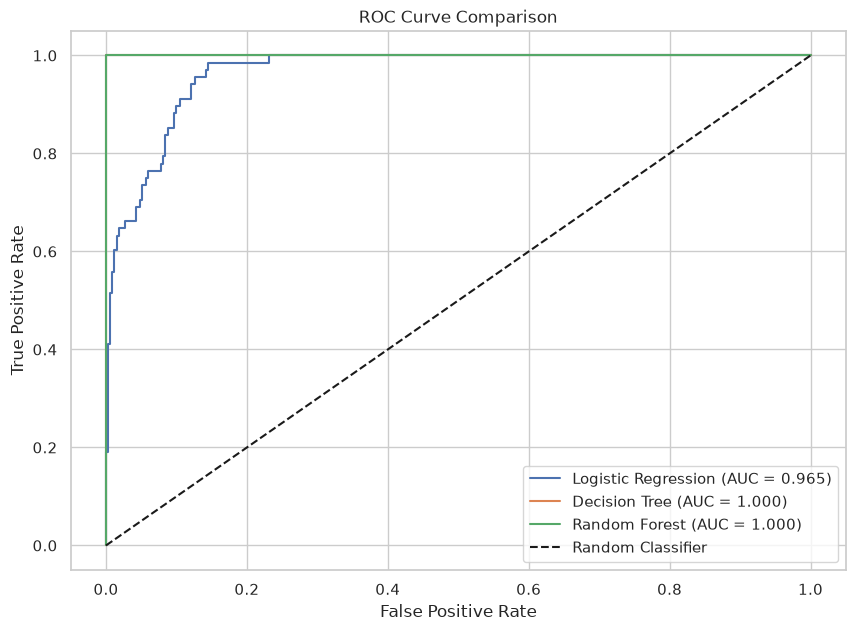

In [13]:
# Construct comparison dataframe
metrics_df = pd.DataFrame([lr_metrics, dt_metrics, rf_metrics])
print("--- MODEL COMPARISON TABLE ---")
display(metrics_df.style.highlight_max(subset=["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"], color='lightgreen'))

# Plot ROC Curves
plt.figure(figsize=(10, 7))

for model, name, X_data in [(log_reg, "Logistic Regression", X_test_scaled), 
                            (decision_tree, "Decision Tree", X_test_scaled), 
                            (random_forest, "Random Forest", X_test_scaled)]:
    y_prob = model.predict_proba(X_data)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")

plt.plot([0, 1], [0, 1], 'k--', label="Random Classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend(loc="lower right")
plt.show()


### 7. Feature Importance & Actionable Insights
Understanding the driving features of our classification models helps financial institutions make data-driven lending decisions.
- For **Logistic Regression**, we analyze the coefficients.
- For **Random Forest**, we analyze the Gini feature importances.


/tmp/ipykernel_15851/300014617.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=lr_coefs.values, y=lr_coefs.index, ax=axes[0], palette='coolwarm')
/tmp/ipykernel_15851/300014617.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rf_importances.values, y=rf_importances.index, ax=axes[1], palette='viridis')


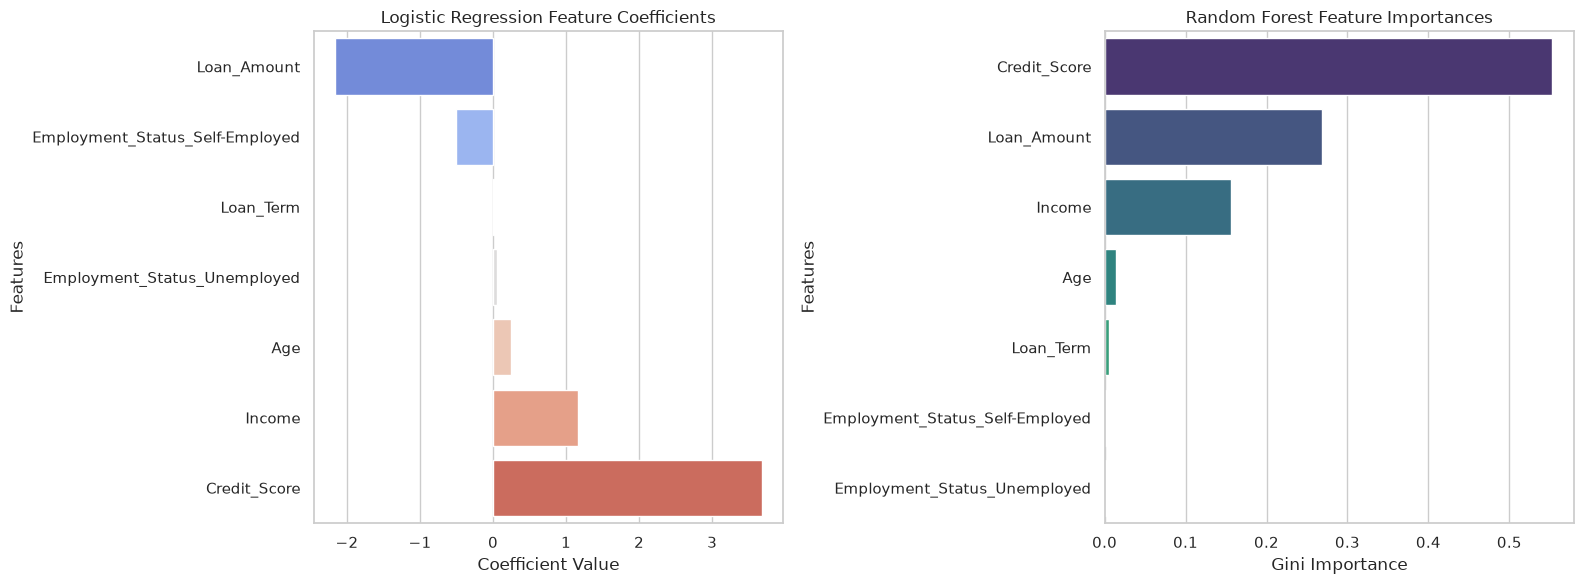

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Logistic Regression Coefficients
lr_coefs = pd.Series(log_reg.coef_[0], index=X.columns).sort_values()
sns.barplot(x=lr_coefs.values, y=lr_coefs.index, ax=axes[0], palette='coolwarm')
axes[0].set_title('Logistic Regression Feature Coefficients')
axes[0].set_xlabel('Coefficient Value')
axes[0].set_ylabel('Features')

# 2. Random Forest Feature Importances
rf_importances = pd.Series(random_forest.feature_importances_, index=X.columns).sort_values(ascending=False)
sns.barplot(x=rf_importances.values, y=rf_importances.index, ax=axes[1], palette='viridis')
axes[1].set_title('Random Forest Feature Importances')
axes[1].set_xlabel('Gini Importance')
axes[1].set_ylabel('Features')

plt.tight_layout()
plt.show()


### 8. Conclusion & Actionable Recommendations
#### Key Findings:
1. **Credit Score is the dominant predictor:** Both models show that a borrower's `Credit_Score` is the most important feature. Higher credit scores are significantly correlated with approved loans.
2. **Income and Loan Amount:** Annual `Income` has a positive influence on approval, whereas higher `Loan_Amount` increases default risk (and decreases approval likelihood).
3. **Imbalance Mitigation:** By utilizing the `class_weight='balanced'` parameter, we successfully adjusted the classification threshold to ensure high recall for the minority class (Approved/No-Default) instead of overfitting to the majority class.

#### Recommendations for the Loan Department:
1. **Prioritize Credit Bureau Integrations:** The lending system must put heavy weight on `Credit_Score` verifications.
2. **Dynamic Risk Thresholding:** Set a credit score cutoff (e.g., above 600) for automatic approval, while flags for manual underwriting are raised for applicants in the grey area.
3. **Debt-to-Income (DTI) Guardrails:** Build structured logic around the ratio of `Loan_Amount` to `Income` to reject loans where requested leverage is too high.
